In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv("data.csv")

df.head(50)

,A,B,Y
0,1.293911,13,15
1,5.838877,24,33
2,2.346042,31,35
3,0.477911,10,11
4,1.534273,20,23
5,4.967251,20,28
6,0.322004,20,21
7,2.112915,17,21
8,5.148941,22,30
9,1.913128,12,15


In [ ]:

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       100 non-null    float64
 1   B       100 non-null    int64  
 2   Y       100 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 2.5 KB


,A,B,Y
count,100.000000,100.000000,100.000000
mean,3.112698,21.100000,26.280000
std,2.303526,7.888747,8.936454
min,0.004248,10.000000,11.000000
25%,1.457042,13.750000,20.000000
50%,2.536842,20.000000,24.000000
75%,4.726967,26.000000,32.250000
max,8.951167,40.000000,50.000000


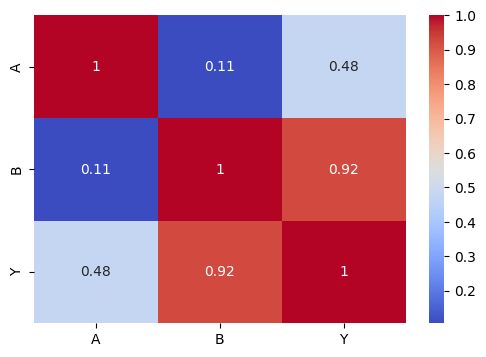

In [ ]:


plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

1. Est-ce qu’on peut prédire B en fonction de A ?
Non la corelation est tres faible.
2. Est-ce qu’on peut prédire Y en fonction de B ? Oui, il ont une tres forte corelation.
3. Est-ce qu’on peut prédire Y en fonction de A et B ? oui mais B aura plus de poids.

In [ ]:
df["diff"] = df["Y"] - df["B"]
df[["A", "diff"]].corr()

,A,diff
A,1.000000,0.996431
diff,0.996431,1.000000


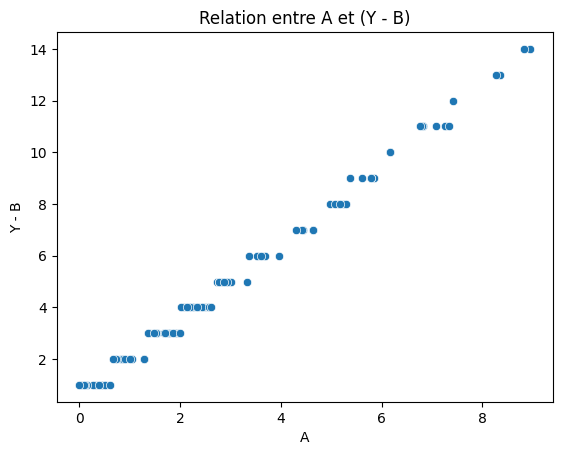

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="A", y="diff")

plt.title("Relation entre A et (Y - B)")
plt.xlabel("A")
plt.ylabel("Y - B")

plt.show()

Cette différence est extrêmement corrélée avec A (0.996), ce qui indique que A explique presque parfaitement la partie de Y qui n'est pas expliquée par B.

In [ ]:
X = df[["A", "B"]]
y = df["Y"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
score = model.score(X_test, y_test)

print("Score R2 :", score)

Score R2 : 0.9991043269774864


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=100,   # nombre d’arbres
    random_state=42 )

model_rf.fit(X_train, y_train)

score_rf = model_rf.score(X_test, y_test)

print("Score Random Forest :", score_rf)

Score Random Forest : 0.9637376035810397


In [16]:
import joblib

joblib.dump(model, 'model.pkl')


['model.pkl']